# Akuisisi Data Saham Batubara IDX dari Yahoo Finance (`yfinance`)

Notebook ini menjelaskan dan mendemonstrasikan proses pengunduhan (*data acquisition*) data historis harga saham harian untuk emiten sektor batubara Indonesia yang terdaftar di Bursa Efek Indonesia (BEI / IDX) menggunakan API **Yahoo Finance** melalui library Python `yfinance`.

### Informasi Dataset:
- **Periode Data**: 2 Januari 2004 – 31 Desember 2024 (21 Tahun)
- **Sumber Data**: Yahoo Finance API (`yfinance`)
- **Frekuensi**: Harian (*Daily Adjusted Close Price*)

### Emiten yang Dianalisis:
1. **ADRO** (`ADRO.JK`) – PT Adaro Energy Indonesia Tbk
2. **PTBA** (`PTBA.JK`) – PT Bukit Asam Tbk
3. **INDY** (`INDY.JK`) – PT Indika Energy Tbk
4. **ITMG** (`ITMG.JK`) – PT Indo Tambangraya Megah Tbk

---

## 1. Import Library

Mengimpor library yang dibutuhkan untuk pengunduhan data, manipulasi time series, dan visualisasi.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import os

## 2. Konfigurasi Ticker dan Periode Data

Menentukan kode ticker Yahoo Finance dan rentang waktu pengambilan data (2 Januari 2004 – 31 Desember 2024).

In [2]:
TICKERS = {
    "ADRO": "ADRO.JK",
    "PTBA": "PTBA.JK",
    "INDY": "INDY.JK",
    "ITMG": "ITMG.JK",
}

START_DATE = "2004-01-01"
END_DATE   = "2024-12-31"

DIR_DATA = "data"
os.makedirs(DIR_DATA, exist_ok=True)

## 3. Unduh Data Historis dari Yahoo Finance

Mengunduh harga penutupan (*Close*) harian untuk keempat emiten batubara menggunakan `yf.download()`.

In [3]:
print("=" * 60)
print("  Mengunduh Data Saham Batubara dari Yahoo Finance...")
print("=" * 60)

ticker_list = list(TICKERS.values())
df_raw = yf.download(ticker_list, start=START_DATE, end=END_DATE)["Close"]

# Rename kolom ke nama emiten
df_raw = df_raw.rename(columns={v: k for k, v in TICKERS.items()})

# Tangani missing value (forward fill lalu backward fill)
df_clean = df_raw.ffill().bfill()

print("\nData berhasil diunduh:")
print(df_clean.head())
print("\nDimensi Dataset:", df_clean.shape)

  Mengunduh Data Saham Batubara dari Yahoo Finance...


[                       0%                       ]

[**********************50%                       ]  2 of 4 completed

[*********************100%***********************]  4 of 4 completed


Data berhasil diunduh:
Ticker            ADRO         INDY         ITMG       PTBA
Date                                                       
2004-01-01  325.636322  1858.861938  2791.716309  31.526564
2004-01-02  325.636322  1858.861938  2791.716309  34.228844
2004-01-05  325.636322  1858.861938  2791.716309  33.328079
2004-01-06  325.636322  1858.861938  2791.716309  32.427326
2004-01-07  325.636322  1858.861938  2791.716309  31.526564

Dimensi Dataset: (5199, 4)


## 4. Perhitungan Log Return Harian

Transformasi harga nominal penutupan menjadi *log return* harian:
$$\text{ret}_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [4]:
df_final = df_clean.copy()

for col in TICKERS.keys():
    df_final[f"ret_{col}"] = np.log(df_final[col] / df_final[col].shift(1))

# Tampilkan ringkasan statistik
print("Ringkasan Statistik Harga Saham:")
print(df_clean.describe())

print("\nRingkasan Statistik Log Return:")
print(df_final[[f"ret_{col}" for col in TICKERS.keys()]].describe())

Ringkasan Statistik Harga Saham:
Ticker         ADRO         INDY          ITMG         PTBA
count   5199.000000  5199.000000   5199.000000  5199.000000
mean     452.528787  1339.808485   6904.768415   821.765479
std      344.806280   668.233764   5627.508783   591.813251
min       88.467674    67.395668    877.151611    23.419731
25%      295.898071   765.750458   2791.716309   397.839478
50%      325.636322  1402.414917   5340.235352   741.911743
75%      435.758942  1858.861938   7824.711426  1027.158203
max     2148.349609  3079.848389  26244.224609  2662.012939

Ringkasan Statistik Log Return:
Ticker     ret_ADRO     ret_PTBA     ret_INDY     ret_ITMG
count   5198.000000  5198.000000  5198.000000  5198.000000
mean       0.000347     0.000828    -0.000043     0.000402
std        0.026239     0.028648     0.030909     0.026530
min       -0.282863    -0.323491    -0.283286    -0.242606
25%       -0.009852    -0.012772    -0.012177    -0.009587
50%        0.000000     0.000000     0.0

## 5. Visualisasi Pergerakan Harga Historis

Plot pergerakan harga historis saham batubara periode 2004–2024 dari data Yahoo Finance.

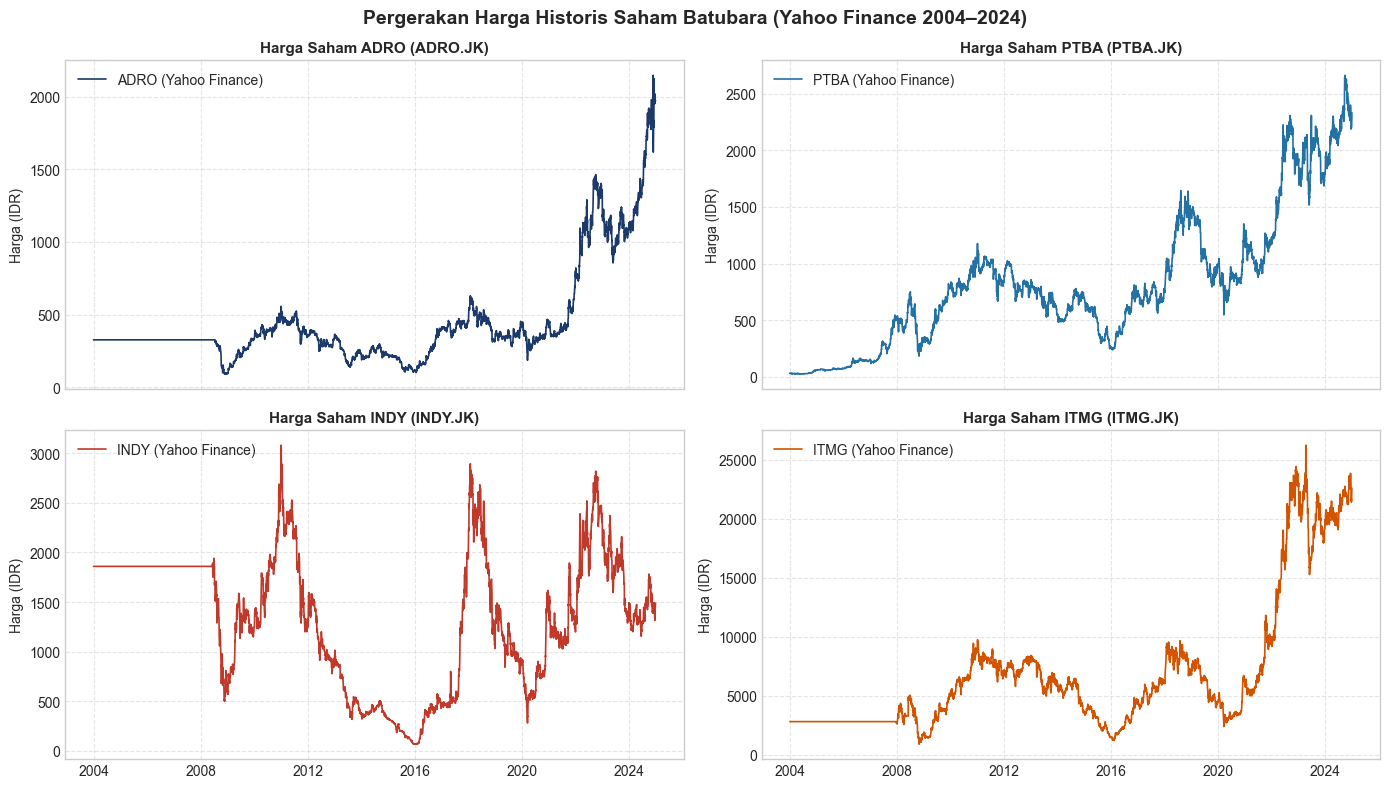

In [5]:
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
colors = ["#1B3A6B", "#2471A3", "#C0392B", "#D35400"]

for idx, (col, color) in enumerate(zip(TICKERS.keys(), colors)):
    ax = axes[idx // 2, idx % 2]
    ax.plot(df_clean.index, df_clean[col], label=f"{col} (Yahoo Finance)", color=color, linewidth=1.2)
    ax.set_title(f"Harga Saham {col} ({TICKERS[col]})", fontsize=11, fontweight="bold")
    ax.set_ylabel("Harga (IDR)")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper left")

plt.suptitle("Pergerakan Harga Historis Saham Batubara (Yahoo Finance 2004–2024)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Simpan Dataset ke Format CSV

Menyimpan data hasil unduhan dari Yahoo Finance ke file `harga_saham_yfinance.csv`.

In [6]:
output_file = os.path.join(DIR_DATA, "harga_saham_yfinance.csv")
df_final.to_csv(output_file)
print(f"Dataset berhasil disimpan ke: {output_file}")

Dataset berhasil disimpan ke: data\harga_saham_yfinance.csv


## 7. Catatan Integrasi dengan Pipeline Modeling

- Dataset yang diunduh langsung dari Yahoo Finance ini dapat digunakan sebagai **alternatif data riil** untuk menggantikan file `harga_saham_batubara.csv` hasil simulasi GBM pada notebook [`preprocessing_eda.ipynb`](file:///c:/Users/dayinta%20agustina/Downloads/Documents/PENELITIAN%20FMIPA%20FORECAST%20FINAL/preprocessing_eda.ipynb).
- Pipeline pemodelan pada [`model_arima.ipynb`](file:///c:/Users/dayinta%20agustina/Downloads/Documents/PENELITIAN%20FMIPA%20FORECAST%20FINAL/model_arima.ipynb) dan [`model_ann_lstm.ipynb`](file:///c:/Users/dayinta%20agustina/Downloads/Documents/PENELITIAN%20FMIPA%20FORECAST%20FINAL/model_ann_lstm.ipynb) dapat langsung membaca file CSV ini dengan struktur kolom yang kompatibel.